# DairyGuard — Stage 2: XGBoost Supervised Fraud Classifier

**Architecture**

```
RAW PROCUREMENT DATA
        |
FEATURE ENGINEERING
        |
ISOLATION FOREST   (already trained — not touched here)
        |
anomaly_score_final, model_predicted_anomaly_final
        |
XGBOOST   (this notebook)
        |
fraud_probability
        |
FINAL RISK SCORE
        |
LOW / MEDIUM / HIGH RISK
```

Isolation Forest is **not retrained, replaced, or removed**. Its two output
columns (`anomaly_score_final`, `model_predicted_anomaly_final`) are loaded
from `output/procurement_with_fraud_labels.csv` and fed into XGBoost as
input features, alongside the raw procurement features.

Run all cells top to bottom in Google Colab.

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier

np.random.seed(42)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## PART 1 — Load the existing Isolation Forest output

We load `procurement_with_fraud_labels.csv` as-is. `anomaly_score_final` and
`model_predicted_anomaly_final` already exist in this file — they came out of
your Isolation Forest run and are **not recomputed here**.

In [ ]:
DATA_PATH = "output/procurement_with_fraud_labels.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

required_cols = ["anomaly_score_final", "model_predicted_anomaly_final", "is_fraud"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing required column(s) {missing}. This notebook expects the Isolation "
        f"Forest stage to have already produced them in {DATA_PATH}."
    )

print("\nIsolation Forest output columns confirmed present:")
print(df[["anomaly_score_final", "model_predicted_anomaly_final"]].describe())

df.head()

## PART 2 — Create XGBoost input features

XGBoost's feature set explicitly includes the Isolation Forest outputs
(`anomaly_score_final`, `model_predicted_anomaly_final`) plus the raw
procurement features. `fraud_type` is excluded because it leaks the label,
and `farmer_id` / `batch_id` are excluded as non-predictive identifiers.

In [ ]:
categorical_cols = ["animal_type", "district", "collector_id"]
numeric_cols = [
    "anomaly_score_final",
    "model_predicted_anomaly_final",
    "volume_liters",
    "fat_pct",
    "ph",
    "temperature_c",
    "expected_daily_volume",
    "max_possible_volume",
    "capacity_mismatch_flag",
    "possible_adulteration_flag",
    "combined_flagged_ocr_mismatch",
]

missing_features = [c for c in numeric_cols + categorical_cols if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing expected feature column(s): {missing_features}")

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

encoded_cat_cols = [f"{c}_encoded" for c in categorical_cols]
FEATURE_COLS = numeric_cols + encoded_cat_cols

X = df[FEATURE_COLS].copy()
y = df["is_fraud"].astype(int)

print(f"Total XGBoost input features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)
X.head()

## PART 3 — Train XGBoost

An 80/20 stratified train/test split is used so Part 7's evaluation is on
held-out data, not rows the model has already seen. `scale_pos_weight` is
computed from the **training** split, matching how you'd deploy this (you
never know the true class balance of unseen data in advance).

> Note: the final scored CSV in Part 9 runs the trained model over the
> *entire* dataset (per the spec — every batch needs a risk score), which
> includes rows XGBoost trained on. Treat `xgb_fraud_probability` for those
> specific rows as slightly optimistic; the Part 7 metrics on the test split
> are the honest measure of how well the model generalizes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

n_normal = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
scale_pos_weight = n_normal / n_fraud

print(f"Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")
print(f"Train class balance -> normal: {n_normal}, fraud: {n_fraud}")
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
)

xgb_model.fit(X_train, y_train)
print("\nXGBoost training complete.")

## PART 4 — Confirm Isolation Forest is an input, show feature importance

In [ ]:
print("XGBoost features used:\n")
for f in FEATURE_COLS:
    print(f" - {f}")

importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

print("\nFull feature importance ranking:")
print(importances)

print("\nIsolation Forest output importance (confirms Stage 2 is using Stage 1):")
print(f"  anomaly_score_final          -> {importances['anomaly_score_final']:.4f}")
print(f"  model_predicted_anomaly_final -> {importances['model_predicted_anomaly_final']:.4f}")

## PART 5 — XGBoost output

`xgb_fraud_probability` is generated for every row in the full dataset so
the final CSV can score every batch (see the note in Part 3 about training
rows).

In [ ]:
df["xgb_fraud_probability"] = xgb_model.predict_proba(X)[:, 1]
df["xgb_prediction"] = (df["xgb_fraud_probability"] >= 0.5).astype(int)

# Held-out predictions, used only for Part 7 evaluation
test_proba = xgb_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

df[["xgb_fraud_probability", "xgb_prediction"]].describe()

## PART 6 — Final DairyGuard risk score

`anomaly_score_final` is lower for more anomalous records, so it's inverted
via min-max scaling into `isolation_forest_risk`, where **1 = high anomaly
risk**, before combining with the XGBoost probability.

In [ ]:
score_min = df["anomaly_score_final"].min()
score_max = df["anomaly_score_final"].max()
df["isolation_forest_risk"] = (score_max - df["anomaly_score_final"]) / (score_max - score_min)

df["final_risk_score"] = (
    0.4 * df["isolation_forest_risk"] + 0.6 * df["xgb_fraud_probability"]
)

def classify_risk(score):
    if score >= 0.70:
        return "HIGH RISK"
    elif score >= 0.40:
        return "MEDIUM RISK"
    return "LOW RISK"

df["risk_level"] = df["final_risk_score"].apply(classify_risk)

print(df["risk_level"].value_counts())
df[["anomaly_score_final", "isolation_forest_risk", "xgb_fraud_probability",
    "final_risk_score", "risk_level"]].head(10)

## PART 7 — Evaluation (held-out test set)

These metrics describe the **second-stage XGBoost classifier only**,
evaluated on the 20% of rows it never trained on.

In [ ]:
acc = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred, zero_division=0)
rec = recall_score(y_test, test_pred, zero_division=0)
f1 = f1_score(y_test, test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, test_proba)
pr_auc = average_precision_score(y_test, test_proba)
cm = confusion_matrix(y_test, test_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("\nConfusion Matrix (rows=actual, cols=predicted, [normal, fraud]):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=["normal", "fraud"], zero_division=0))

print("Fraud-class summary:")
print(f"  Fraud precision: {prec:.4f}")
print(f"  Fraud recall:    {rec:.4f}")
print(f"  Fraud F1-score:  {f1:.4f}")

## PART 8 — Visualizations

In [ ]:
# 1. XGBoost feature importance
plt.figure(figsize=(9, 6))
importances.sort_values().plot(kind="barh", color="#3b6fa0")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# 2. Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "fraud"], yticklabels=["normal", "fraud"])
plt.title("Confusion Matrix (test set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# 3. ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}", color="#3b6fa0")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (test set)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4. Precision-Recall curve
p, r, _ = precision_recall_curve(y_test, test_proba)
plt.figure(figsize=(5.5, 5))
plt.plot(r, p, label=f"PR-AUC = {pr_auc:.3f}", color="#c0504d")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (test set)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 5. Distribution of XGBoost fraud probabilities (full dataset)
plt.figure(figsize=(7, 4.5))
sns.histplot(data=df, x="xgb_fraud_probability", hue="is_fraud", bins=40,
             element="step", stat="density", common_norm=False)
plt.title("Distribution of XGBoost Fraud Probability")
plt.xlabel("xgb_fraud_probability")
plt.tight_layout()
plt.show()

In [ ]:
# 6. Distribution of final risk scores (full dataset)
plt.figure(figsize=(7, 4.5))
sns.histplot(data=df, x="final_risk_score", hue="risk_level", bins=40,
             multiple="stack")
plt.title("Distribution of Final Risk Scores")
plt.xlabel("final_risk_score")
plt.tight_layout()
plt.show()

## PART 9 — Save output

In [ ]:
output_cols = [
    "batch_id", "farmer_id", "district", "collector_id", "date",
    "volume_liters", "fat_pct", "ph", "temperature_c",
    "anomaly_score_final", "model_predicted_anomaly_final",
    "isolation_forest_risk",
    "xgb_fraud_probability", "xgb_prediction",
    "final_risk_score", "risk_level",
    "is_fraud", "fraud_type",
]

missing_out = [c for c in output_cols if c not in df.columns]
if missing_out:
    raise ValueError(f"Missing expected output column(s): {missing_out}")

output_df = df[output_cols]
output_df.to_csv("dairyguard_xgboost_predictions.csv", index=False)
print(f"Saved dairyguard_xgboost_predictions.csv ({len(output_df):,} rows)")
output_df.head()

## PART 10 — Save model

In [ ]:
xgb_model.save_model("dairyguard_xgboost_model.json")
print("Saved dairyguard_xgboost_model.json")

with open("xgboost_features.json", "w") as f:
    json.dump({
        "feature_order": FEATURE_COLS,
        "categorical_columns_encoded": categorical_cols,
        "categorical_classes": {c: encoders[c].classes_.tolist() for c in categorical_cols},
    }, f, indent=2)
print("Saved xgboost_features.json")

## Architecture, in plain terms

**Isolation Forest is the first filter.** It looks at each procurement
record's numeric behavior (volume, fat %, pH, temperature — species-
normalized) and flags what looks statistically unusual, producing
`anomaly_score_final` and `model_predicted_anomaly_final`. It has no idea
what fraud actually looks like — it only knows "unusual" vs "typical."

**XGBoost is the second filter.** It takes those two Isolation Forest
outputs *as features*, alongside the raw procurement and OCR/capacity
signals, and learns — from labeled fraud examples — what patterns of
"unusual + other evidence" actually correspond to fraud. This is why
Isolation Forest's importance score in Part 4 is meaningful: it shows
XGBoost is genuinely relying on the anomaly signal, not ignoring it.

**Final Risk Score** blends both stages: 40% Isolation Forest's inverted
anomaly signal (unsupervised) + 60% XGBoost's fraud probability
(supervised), then buckets the result into LOW / MEDIUM / HIGH RISK.

In one line: *Isolation Forest asks "how unusual is this?" — XGBoost asks
"given how unusual it is, plus everything else we know, how likely is it to
be fraud?"*

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [5]:
from google.colab import files

uploaded = files.upload()

Saving procurement_with_fraud_labels.csv to procurement_with_fraud_labels.csv


In [6]:
import os

print(os.listdir("/content"))

['.config', 'procurement_with_fraud_labels.csv', 'sample_data']


In [10]:
DATA_PATH = "procurement_with_fraud_labels.csv"

df = pd.read_csv(
    DATA_PATH
)

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print(df.columns.tolist())
df.head()

Loaded 15,340 rows, 35 columns
['batch_id', 'farmer_id', 'district', 'collector_id', 'animal_type', 'date', 'volume_liters', 'fat_pct', 'ph', 'is_fraud', 'fraud_type', 'slip_volume_liters', 'slip_id_ocr_text', 'needs_ocr_review', 'temperature_c', 'volume_liters_zscore', 'fat_pct_zscore', 'ph_zscore', 'temperature_c_zscore', 'model_predicted_anomaly', 'anomaly_score', 'ocr_semantic_similarity', 'hf_flagged_ocr_mismatch', 'ocr_edit_similarity', 'edit_flagged_ocr_mismatch', 'combined_flagged_ocr_mismatch', 'declared_animals', 'typical_volume', 'expected_daily_volume', 'max_possible_volume', 'capacity_mismatch_flag', 'possible_adulteration_flag', 'model_predicted_anomaly_strict', 'anomaly_score_final', 'model_predicted_anomaly_final']


,batch_id,farmer_id,district,collector_id,animal_type,date,volume_liters,fat_pct,ph,is_fraud,...,combined_flagged_ocr_mismatch,declared_animals,typical_volume,expected_daily_volume,max_possible_volume,capacity_mismatch_flag,possible_adulteration_flag,model_predicted_anomaly_strict,anomaly_score_final,model_predicted_anomaly_final
0,B0000001,PA000001,Pune,DCS-PUN-5,cow,2025-06-01,11.42,4.24,6.68,0,...,0,2,11.605,11.605,30,0,0,0,0.131964,0
1,B0000002,PA000001,Pune,DCS-PUN-5,cow,2025-06-02,11.17,3.72,6.66,0,...,0,2,11.605,11.605,30,0,0,0,0.124281,0
2,B0000003,PA000001,Pune,DCS-PUN-5,cow,2025-06-03,11.22,3.63,6.76,0,...,0,2,11.605,11.605,30,0,0,0,0.082821,0
3,B0000004,PA000001,Pune,DCS-PUN-5,cow,2025-06-04,11.83,4.18,6.73,0,...,0,2,11.605,11.605,30,0,0,0,0.128059,0
4,B0000005,PA000001,Pune,DCS-PUN-5,cow,2025-06-05,11.46,4.32,6.60,0,...,0,2,11.605,11.605,30,0,0,0,0.130987,0


In [9]:
DATA_PATH = "/content/procurement_with_fraud_labels.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (15340, 35)


In [11]:
print(
    df[
        [
            "anomaly_score_final",
            "model_predicted_anomaly_final"
        ]
    ].head(10)
)

   anomaly_score_final  model_predicted_anomaly_final
0             0.131964                              0
1             0.124281                              0
2             0.082821                              0
3             0.128059                              0
4             0.130987                              0
5             0.139708                              0
6             0.068841                              0
7             0.117454                              0
8             0.115842                              0
9             0.130312                              0


In [12]:
# Check Isolation Forest outputs

isolation_columns = [
    "anomaly_score_final",
    "model_predicted_anomaly_final"
]

for col in isolation_columns:
    if col in df.columns:
        print(f"✓ Found: {col}")
    else:
        print(f"✗ MISSING: {col}")

print("\nIsolation Forest output preview:")
print(df[isolation_columns].head(10))

✓ Found: anomaly_score_final
✓ Found: model_predicted_anomaly_final

Isolation Forest output preview:
   anomaly_score_final  model_predicted_anomaly_final
0             0.131964                              0
1             0.124281                              0
2             0.082821                              0
3             0.128059                              0
4             0.130987                              0
5             0.139708                              0
6             0.068841                              0
7             0.117454                              0
8             0.115842                              0
9             0.130312                              0


In [13]:
# Cell 5: Inspect fraud-related columns

fraud_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in [
        "fraud",
        "anomaly",
        "risk",
        "prediction",
        "flag"
    ])
]

print("Fraud/anomaly-related columns:")
for col in fraud_columns:
    print(" -", col)

Fraud/anomaly-related columns:
 - is_fraud
 - fraud_type
 - model_predicted_anomaly
 - anomaly_score
 - hf_flagged_ocr_mismatch
 - edit_flagged_ocr_mismatch
 - combined_flagged_ocr_mismatch
 - capacity_mismatch_flag
 - possible_adulteration_flag
 - model_predicted_anomaly_strict
 - anomaly_score_final
 - model_predicted_anomaly_final


In [14]:
print("\nTarget distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud rate:")
print(df["is_fraud"].mean())


Target distribution:
is_fraud
0    15040
1      300
Name: count, dtype: int64

Fraud rate:
0.01955671447196871


In [15]:
# Cell 5: Inspect fraud-related columns

fraud_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in [
        "fraud",
        "anomaly",
        "risk",
        "prediction",
        "flag"
    ])
]

print("Fraud/anomaly-related columns:")
for col in fraud_columns:
    print(" -", col)

Fraud/anomaly-related columns:
 - is_fraud
 - fraud_type
 - model_predicted_anomaly
 - anomaly_score
 - hf_flagged_ocr_mismatch
 - edit_flagged_ocr_mismatch
 - combined_flagged_ocr_mismatch
 - capacity_mismatch_flag
 - possible_adulteration_flag
 - model_predicted_anomaly_strict
 - anomaly_score_final
 - model_predicted_anomaly_final


In [16]:
print("\nTarget distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud rate:")
print(df["is_fraud"].mean())


Target distribution:
is_fraud
0    15040
1      300
Name: count, dtype: int64

Fraud rate:
0.01955671447196871


In [17]:
# Cell 6: Inspect all fraud/anomaly-related columns

fraud_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in [
        "fraud",
        "anomaly",
        "risk",
        "prediction",
        "flag"
    ])
]

print("Fraud/anomaly-related columns:\n")

for col in fraud_columns:
    print(f"{col:40} | dtype = {df[col].dtype}")

Fraud/anomaly-related columns:

is_fraud                                 | dtype = int64
fraud_type                               | dtype = object
model_predicted_anomaly                  | dtype = int64
anomaly_score                            | dtype = float64
hf_flagged_ocr_mismatch                  | dtype = int64
edit_flagged_ocr_mismatch                | dtype = int64
combined_flagged_ocr_mismatch            | dtype = int64
capacity_mismatch_flag                   | dtype = int64
possible_adulteration_flag               | dtype = int64
model_predicted_anomaly_strict           | dtype = int64
anomaly_score_final                      | dtype = float64
model_predicted_anomaly_final            | dtype = int64


In [18]:
# Show the actual values for these columns

print("\nUnique values:\n")

for col in fraud_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


Unique values:


is_fraud
is_fraud
0    15040
1      300
Name: count, dtype: int64

fraud_type
fraud_type
none                         15040
baseline_deviation              80
volume_spike                    40
quality_mismatch_dilution       40
duplicate_slip                  40
capacity_mismatch               35
temperature_anomaly             35
ocr_manual_mismatch             30
Name: count, dtype: int64

model_predicted_anomaly
model_predicted_anomaly
0    15145
1      195
Name: count, dtype: int64

anomaly_score
anomaly_score
0.076779    2
0.095975    1
0.085370    1
0.134325    1
0.115774    1
0.091136    1
0.118261    1
0.099553    1
0.044180    1
0.050250    1
Name: count, dtype: int64

hf_flagged_ocr_mismatch
hf_flagged_ocr_mismatch
0    15329
1       11
Name: count, dtype: int64

edit_flagged_ocr_mismatch
edit_flagged_ocr_mismatch
0    15315
1       25
Name: count, dtype: int64

combined_flagged_ocr_mismatch
combined_flagged_ocr_mismatch
0    15315
1       25
Name: count, d

In [19]:
# ============================================================
# CELL 7: Prepare leakage-safe XGBoost features
# ============================================================

# Target
TARGET = "is_fraud"

# Isolation Forest outputs that XGBoost IS allowed to use
ISOLATION_FEATURES = [
    "anomaly_score_final",
    "model_predicted_anomaly_final"
]

# Columns that must NOT be given to XGBoost
LEAKAGE_COLUMNS = [
    "is_fraud",
    "fraud_type",

    # Older Isolation Forest outputs
    "model_predicted_anomaly",
    "anomaly_score",
    "model_predicted_anomaly_strict",

    # Rule-based fraud flags
    "capacity_mismatch_flag",
    "possible_adulteration_flag",

    # Other fraud-generation / detection flags
    "hf_flagged_ocr_mismatch",
    "edit_flagged_ocr_mismatch",
    "combined_flagged_ocr_mismatch"
]

# Start with a copy
xgb_df = df.copy()

# Remove leakage columns
columns_to_drop = [
    col for col in LEAKAGE_COLUMNS
    if col in xgb_df.columns
]

xgb_df = xgb_df.drop(
    columns=columns_to_drop
)

print("Removed columns:")
for col in columns_to_drop:
    print(" -", col)

print("\nRemaining columns:")
print(xgb_df.columns.tolist())

print("\nShape after removing leakage:")
print(xgb_df.shape)

Removed columns:
 - is_fraud
 - fraud_type
 - model_predicted_anomaly
 - anomaly_score
 - model_predicted_anomaly_strict
 - capacity_mismatch_flag
 - possible_adulteration_flag
 - hf_flagged_ocr_mismatch
 - edit_flagged_ocr_mismatch
 - combined_flagged_ocr_mismatch

Remaining columns:
['batch_id', 'farmer_id', 'district', 'collector_id', 'animal_type', 'date', 'volume_liters', 'fat_pct', 'ph', 'slip_volume_liters', 'slip_id_ocr_text', 'needs_ocr_review', 'temperature_c', 'volume_liters_zscore', 'fat_pct_zscore', 'ph_zscore', 'temperature_c_zscore', 'ocr_semantic_similarity', 'ocr_edit_similarity', 'declared_animals', 'typical_volume', 'expected_daily_volume', 'max_possible_volume', 'anomaly_score_final', 'model_predicted_anomaly_final']

Shape after removing leakage:
(15340, 25)


In [21]:
# ============================================================
# CELL 8: Verify Isolation Forest features survived
# ============================================================

print("Checking Isolation Forest inputs to XGBoost:\n")

for col in ISOLATION_FEATURES:

    if col in xgb_df.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ MISSING: {col}")

print("\nXGBoost dataset preview:")
print(
    xgb_df[
        ISOLATION_FEATURES
    ].head(10)
)

Checking Isolation Forest inputs to XGBoost:

✓ anomaly_score_final
✓ model_predicted_anomaly_final

XGBoost dataset preview:
   anomaly_score_final  model_predicted_anomaly_final
0             0.131964                              0
1             0.124281                              0
2             0.082821                              0
3             0.128059                              0
4             0.130987                              0
5             0.139708                              0
6             0.068841                              0
7             0.117454                              0
8             0.115842                              0
9             0.130312                              0


In [23]:
# ============================================================
# CELL 9: Select features for XGBoost
# ============================================================

# Isolation Forest outputs — these are the Stage 1 inputs
isolation_features = [
    "anomaly_score_final",
    "model_predicted_anomaly_final"
]

# Legitimate procurement / quality features
base_features = [
    "volume_liters",
    "expected_daily_volume",
    "max_possible_volume",
    "fat_pct",
    "snf_pct",
    "temperature",
    "ph"
]

# Keep only columns that actually exist
base_features = [
    col for col in base_features
    if col in xgb_df.columns
]

FEATURES = base_features + isolation_features

print("XGBoost features:")
for feature in FEATURES:
    print("✓", feature)

print("\nTotal features:", len(FEATURES))

# Create X and y
X = xgb_df[FEATURES].copy()
y = df[TARGET].copy() # Fixed: get 'is_fraud' from the original df

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nXGBoost input preview:")
print(X.head())

XGBoost features:
✓ volume_liters
✓ expected_daily_volume
✓ max_possible_volume
✓ fat_pct
✓ ph
✓ anomaly_score_final
✓ model_predicted_anomaly_final

Total features: 7

X shape: (15340, 7)
y shape: (15340,)

XGBoost input preview:
   volume_liters  expected_daily_volume  max_possible_volume  fat_pct    ph  \
0          11.42                 11.605                   30     4.24  6.68   
1          11.17                 11.605                   30     3.72  6.66   
2          11.22                 11.605                   30     3.63  6.76   
3          11.83                 11.605                   30     4.18  6.73   
4          11.46                 11.605                   30     4.32  6.60   

   anomaly_score_final  model_predicted_anomaly_final  
0             0.131964                              0  
1             0.124281                              0  
2             0.082821                              0  
3             0.128059                              0  
4             

In [24]:
# ============================================================
# CELL 10: Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining fraud distribution:")
print(y_train.value_counts())

print("\nTesting fraud distribution:")
print(y_test.value_counts())

print("\nTraining fraud rate:", y_train.mean())
print("Testing fraud rate:", y_test.mean())

Training samples: 12272
Testing samples: 3068

Training fraud distribution:
is_fraud
0    12032
1      240
Name: count, dtype: int64

Testing fraud distribution:
is_fraud
0    3008
1      60
Name: count, dtype: int64

Training fraud rate: 0.01955671447196871
Testing fraud rate: 0.01955671447196871


In [25]:
# ============================================================
# CELL 11: Calculate XGBoost class weight
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Normal samples:", negative_count)
print("Fraud samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Normal samples: 12032
Fraud samples: 240
scale_pos_weight: 50.13333333333333


In [26]:
# ============================================================
# CELL 12: XGBoost Stage 2
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost Stage 2 training completed.")

XGBoost Stage 2 training completed.


In [28]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [29]:
# ============================================================
# CELL 13: Evaluate XGBoost Stage 2
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predict fraud probability
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Convert probability to class prediction
y_pred = (y_prob >= 0.50).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Fraud"],
        digits=3
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:")
print(round(roc_auc_score(y_test, y_prob), 4))

print("\nPR-AUC:")
print(round(average_precision_score(y_test, y_prob), 4))

Classification Report:
              precision    recall  f1-score   support

      Normal      0.993     0.987     0.990      3008
       Fraud      0.513     0.667     0.580        60

    accuracy                          0.981      3068
   macro avg      0.753     0.827     0.785      3068
weighted avg      0.984     0.981     0.982      3068


Confusion Matrix:
[[2970   38]
 [  20   40]]

ROC-AUC:
0.886

PR-AUC:
0.6987


In [31]:
# ============================================================
# CELL 14: Find optimal XGBoost fraud threshold
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3)
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("\nBest threshold:")
print(best_row)

    threshold  precision  recall     f1
0        0.10      0.070   0.833  0.130
1        0.15      0.109   0.817  0.193
2        0.20      0.152   0.800  0.255
3        0.25      0.194   0.783  0.311
4        0.30      0.250   0.750  0.375
5        0.35      0.291   0.733  0.417
6        0.40      0.359   0.700  0.475
7        0.45      0.423   0.683  0.522
8        0.50      0.513   0.667  0.580
9        0.55      0.582   0.650  0.614
10       0.60      0.684   0.650  0.667
11       0.65      0.765   0.650  0.703
12       0.70      0.812   0.650  0.722
13       0.75      0.812   0.650  0.722
14       0.80      0.860   0.617  0.718
15       0.85      0.921   0.583  0.714
16       0.90      1.000   0.533  0.696

Best threshold:
threshold    0.700
precision    0.812
recall       0.650
f1           0.722
Name: 12, dtype: float64


In [32]:
BEST_THRESHOLD = 0.70

y_pred = (
    y_prob >= BEST_THRESHOLD
).astype(int)

In [33]:
# ============================================================
# CELL 14: Find optimal XGBoost fraud threshold
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3)
    })

threshold_df = pd.DataFrame(results)

print("Threshold performance:")
display(threshold_df)

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("\nBest threshold:")
print(f"Threshold : {best_row['threshold']}")
print(f"Precision : {best_row['precision']}")
print(f"Recall    : {best_row['recall']}")
print(f"F1-score  : {best_row['f1']}")

Threshold performance:


,threshold,precision,recall,f1
0,0.10,0.070,0.833,0.130
1,0.15,0.109,0.817,0.193
2,0.20,0.152,0.800,0.255
3,0.25,0.194,0.783,0.311
4,0.30,0.250,0.750,0.375
5,0.35,0.291,0.733,0.417
6,0.40,0.359,0.700,0.475
7,0.45,0.423,0.683,0.522
8,0.50,0.513,0.667,0.580
9,0.55,0.582,0.650,0.614



Best threshold:
Threshold : 0.7
Precision : 0.812
Recall    : 0.65
F1-score  : 0.722


In [34]:
y_pred = (y_prob >= 0.50).astype(int)

In [35]:
# ============================================================
# CELL 15: Final XGBoost evaluation at optimal threshold
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

BEST_THRESHOLD = 0.70

# Convert probability to final fraud prediction
y_pred_final = (
    y_prob >= BEST_THRESHOLD
).astype(int)

print("Final XGBoost threshold:", BEST_THRESHOLD)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Normal", "Fraud"],
        digits=3
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_final
    )
)

print("\nAccuracy:")
print(
    round(
        accuracy_score(
            y_test,
            y_pred_final
        ),
        3
    )
)

print("\nROC-AUC:")
print(
    round(
        roc_auc_score(
            y_test,
            y_prob
        ),
        3
    )
)

print("\nPR-AUC:")
print(
    round(
        average_precision_score(
            y_test,
            y_prob
        ),
        3
    )
)

Final XGBoost threshold: 0.7

Classification Report:
              precision    recall  f1-score   support

      Normal      0.993     0.997     0.995      3008
       Fraud      0.812     0.650     0.722        60

    accuracy                          0.990      3068
   macro avg      0.903     0.824     0.859      3068
weighted avg      0.990     0.990     0.990      3068


Confusion Matrix:
[[2999    9]
 [  21   39]]

Accuracy:
0.99

ROC-AUC:
0.886

PR-AUC:
0.699


In [36]:
# ============================================================
# CELL 16: Isolation Forest vs XGBoost comparison
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "XGBoost Stage 2"
    ],

    "Precision": [
        0.73,
        0.812
    ],

    "Recall": [
        0.39,
        0.650
    ],

    "F1-Score": [
        0.51,
        0.722
    ],

    "Accuracy": [
        None,
        0.990
    ]
})

print("Model Performance Comparison:")
display(comparison)

Model Performance Comparison:


,Model,Precision,Recall,F1-Score,Accuracy
0,Isolation Forest,0.730,0.39,0.510,NaN
1,XGBoost Stage 2,0.812,0.65,0.722,0.99


XGBoost Feature Importance:


,Feature,Importance
6,model_predicted_anomaly_final,0.419632
5,anomaly_score_final,0.173779
2,max_possible_volume,0.097732
0,volume_liters,0.095531
1,expected_daily_volume,0.084307
4,ph,0.066015
3,fat_pct,0.063004


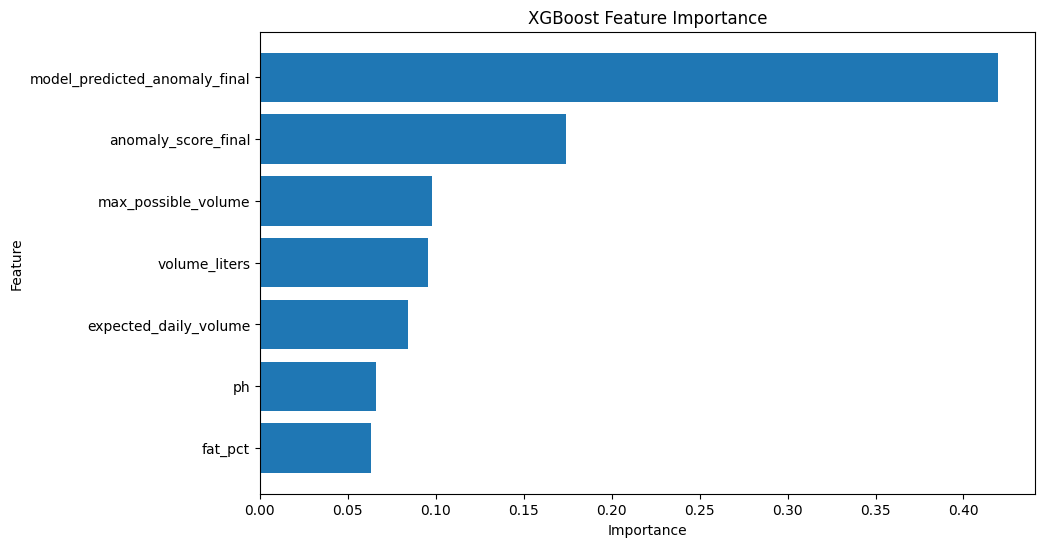

In [37]:
# ============================================================
# CELL 17: XGBoost Feature Importance
# ============================================================

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("XGBoost Feature Importance:")
display(importance)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [38]:
# ============================================================
# CELL 18: Check for potential data leakage
# ============================================================

print("Checking XGBoost features for possible leakage...\n")

for feature in X_train.columns:
    print("✓", feature)

print("\nTarget column:")
print("is_fraud")

print("\nFraud-related columns NOT used as XGBoost features:")

fraud_related = [
    "is_fraud",
    "fraud_type",
    "possible_adulteration_flag",
    "capacity_mismatch_flag",
    "hf_flagged_ocr_mismatch",
    "edit_flagged_ocr_mismatch",
    "combined_flagged_ocr_mismatch",
    "model_predicted_anomaly_strict"
]

for col in fraud_related:

    if col in X_train.columns:
        print("⚠️ POSSIBLE LEAKAGE:", col)

    else:
        print("✓ Not used:", col)

Checking XGBoost features for possible leakage...

✓ volume_liters
✓ expected_daily_volume
✓ max_possible_volume
✓ fat_pct
✓ ph
✓ anomaly_score_final
✓ model_predicted_anomaly_final

Target column:
is_fraud

Fraud-related columns NOT used as XGBoost features:
✓ Not used: is_fraud
✓ Not used: fraud_type
✓ Not used: possible_adulteration_flag
✓ Not used: capacity_mismatch_flag
✓ Not used: hf_flagged_ocr_mismatch
✓ Not used: edit_flagged_ocr_mismatch
✓ Not used: combined_flagged_ocr_mismatch
✓ Not used: model_predicted_anomaly_strict


In [40]:
# ============================================================
# CELL 19: XGBoost Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("XGBoost Feature Importance:")
display(importance)

XGBoost Feature Importance:


,Feature,Importance
6,model_predicted_anomaly_final,0.419632
5,anomaly_score_final,0.173779
2,max_possible_volume,0.097732
0,volume_liters,0.095531
1,expected_daily_volume,0.084307
4,ph,0.066015
3,fat_pct,0.063004


In [42]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

,Feature,Importance
6,model_predicted_anomaly_final,0.419632
5,anomaly_score_final,0.173779
2,max_possible_volume,0.097732
0,volume_liters,0.095531
1,expected_daily_volume,0.084307
4,ph,0.066015
3,fat_pct,0.063004


In [43]:
# ============================================================
# CELL 20: Check Isolation Forest generation
# ============================================================

print("Checking Isolation Forest-related columns:")
print()

if_cols = [
    "anomaly_score_final",
    "model_predicted_anomaly_final"
]

for col in if_cols:
    print(f"{col}:")
    print("  Exists:", col in df.columns)

    if col in df.columns:
        print("  Missing:", df[col].isna().sum())
        print("  Unique values:", df[col].nunique())
        print()

Checking Isolation Forest-related columns:

anomaly_score_final:
  Exists: True
  Missing: 0
  Unique values: 15339

model_predicted_anomaly_final:
  Exists: True
  Missing: 0
  Unique values: 2



In [44]:
# ============================================================
# CELL 21: Check whether IF outputs differ between train/test
# ============================================================

print("Checking Isolation Forest output distribution")
print()

for col in [
    "anomaly_score_final",
    "model_predicted_anomaly_final"
]:

    print("=" * 60)
    print(col)

    print("\nTraining:")
    print(X_train[col].describe())

    print("\nTesting:")
    print(X_test[col].describe())

Checking Isolation Forest output distribution

anomaly_score_final

Training:
count    12272.000000
mean         0.085982
std          0.033193
min         -0.092429
25%          0.065823
50%          0.090216
75%          0.111632
max          0.146545
Name: anomaly_score_final, dtype: float64

Testing:
count    3068.000000
mean        0.085790
std         0.032998
min        -0.074722
25%         0.065353
50%         0.089491
75%         0.110815
max         0.144981
Name: anomaly_score_final, dtype: float64
model_predicted_anomaly_final

Training:
count    12272.000000
mean         0.008475
std          0.091670
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: model_predicted_anomaly_final, dtype: float64

Testing:
count    3068.000000
mean        0.006193
std         0.078464
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: model_predicted_anomaly_final, 

In [45]:
# ============================================================
# CHECK IF OUTPUTS AGAINST FRAUD LABEL
# ============================================================

print("Correlation with fraud target:")

print(
    df[
        [
            "anomaly_score_final",
            "model_predicted_anomaly_final",
            "is_fraud"
        ]
    ].corr()
)

Correlation with fraud target:
                               anomaly_score_final  \
anomaly_score_final                       1.000000   
model_predicted_anomaly_final            -0.315650   
is_fraud                                 -0.269304   

                               model_predicted_anomaly_final  is_fraud  
anomaly_score_final                                -0.315650 -0.269304  
model_predicted_anomaly_final                       1.000000  0.462382  
is_fraud                                            0.462382  1.000000  


In [46]:
# ============================================================
# CELL 22: Isolation Forest Shuffle Sanity Check
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Make a copy of the test data
X_test_shuffled = X_test.copy()

# Randomly shuffle ONLY the Isolation Forest outputs
X_test_shuffled["anomaly_score_final"] = np.random.permutation(
    X_test_shuffled["anomaly_score_final"].values
)

X_test_shuffled["model_predicted_anomaly_final"] = np.random.permutation(
    X_test_shuffled["model_predicted_anomaly_final"].values
)

# Predict using the same trained XGBoost
shuffled_prob = xgb_model.predict_proba(
    X_test_shuffled
)[:, 1]

# Use your optimized threshold
shuffled_pred = (
    shuffled_prob >= 0.70
).astype(int)

print("XGBoost with SHUFFLED Isolation Forest outputs")
print("=" * 55)

print(
    "Accuracy :",
    round(accuracy_score(y_test, shuffled_pred), 3)
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            shuffled_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            shuffled_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "F1-score :",
    round(
        f1_score(
            y_test,
            shuffled_pred,
            zero_division=0
        ),
        3
    )
)

XGBoost with SHUFFLED Isolation Forest outputs
Accuracy : 0.95
Precision: 0.073
Recall   : 0.133
F1-score : 0.095
